In [ ]:
# 🔧 Imports
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 📡 Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"📡 Using device: {device}")

# 📁 Load raw prices
file_path = "C:/Users/Shashwat/OneDrive/Desktop/ALL new resumes/CONSITUTIONAL LAW/SALARAY SLIP/GWP1_ML_IN_FINANCE/combined_data_2020_2024.csv"
raw_df = pd.read_csv(file_path, index_col=0, parse_dates=True).dropna()

# ✅ Convert to log returns
log_returns_df = np.log(raw_df / raw_df.shift(1)).dropna()

# 🔁 Feature Engineering on log returns
def add_features(df, window=5):
    features = {}
    for col in df.columns:
        features[f"{col}_ret"] = df[col]
        features[f"{col}_vol"] = df[col].rolling(window).std()
        features[f"{col}_mean"] = df[col].rolling(window).mean()
        features[f"{col}_sharpe"] = features[f"{col}_mean"] / (features[f"{col}_vol"] + 1e-8)
    return pd.DataFrame(features).dropna()

features_df = add_features(log_returns_df).sort_index(axis=1)

# 📅 Train-test split
train_df = features_df[features_df.index < "2024-01-01"]
test_df = features_df[features_df.index >= "2024-01-01"]
train_returns = log_returns_df.loc[train_df.index]
test_returns = log_returns_df.loc[test_df.index]

print("✅ Features created and split.")
print(f"Train shape: {train_df.shape}, Test shape: {test_df.shape}")

# 🧱 Custom Environment
class FeaturePortfolioEnv:
    def __init__(self, features_df, returns_df, seq_len=10):
        self.features = torch.tensor(features_df.values, dtype=torch.float32).to(device)
        self.returns = torch.tensor(returns_df.values, dtype=torch.float32).to(device)
        self.seq_len = seq_len
        self.n_assets = returns_df.shape[1]
        self.n_features = self.features.shape[1]
        self.reset()

    def reset(self):
        self.ptr = self.seq_len
        return self.features[self.ptr - self.seq_len:self.ptr].unsqueeze(0)

    def step(self, allocation_weights):
        today_return = self.returns[self.ptr]
        reward = torch.dot(allocation_weights[0], today_return)
        self.ptr += 1
        done = self.ptr >= len(self.returns)
        next_state = self.features[self.ptr - self.seq_len:self.ptr].unsqueeze(0) if not done else None
        return next_state, reward, done

# 🤖 LSTM Policy
class LSTMSoftPolicy(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, input_dim // 4)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        logits = self.fc(hn.squeeze(0))
        return self.softmax(logits)

# 🏋️ Training loop
def train_soft_policy(env, model, epochs=200, gamma=0.99, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    rewards_all = []

    for epoch in range(epochs):
        state = env.reset()
        log_probs, rewards = [], []
        done = False

        while not done:
            action_probs = model(state)
            m = torch.distributions.Categorical(probs=action_probs.squeeze(0))
            action = m.sample()
            log_prob = torch.log(action_probs[0, action])
            allocation = action_probs

            next_state, reward, done = env.step(allocation)
            log_probs.append(log_prob)
            rewards.append(reward)
            state = next_state

        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)
        returns = torch.tensor(returns, dtype=torch.float32).to(device)

        loss = -torch.stack(log_probs).dot(returns)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        rewards_all.append(torch.sum(torch.tensor(rewards)).item())
        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1} 🎯 Reward: {rewards_all[-1]:.4f}")

    return rewards_all

# 🔁 Setup environment and model
seq_len = 10
train_env = FeaturePortfolioEnv(train_df, train_returns, seq_len)
input_dim = train_env.n_features
model = LSTMSoftPolicy(input_dim).to(device)

# 🚀 Train
if device.type == "cuda":
    print(f"Allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
    torch.cuda.empty_cache()

print("🚀 Training soft-allocation LSTM model...")
try:
    train_rewards = train_soft_policy(train_env, model, epochs=300)
except RuntimeError as e:
    print("❌ CUDA RuntimeError:", e)
    torch.cuda.empty_cache()
    raise

# 🧪 Model sanity check
sample_input = train_env.reset()
out = model(sample_input)
print("✅ LSTM output shape:", out.shape)
print("✅ LSTM output (weights):", out.detach().cpu().numpy())

# 📈 Plot rewards
plt.figure(figsize=(10, 4))
plt.plot(train_rewards)
plt.title("🎯 Cumulative Reward per Episode (Training)")
plt.xlabel("Episode")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.tight_layout()
plt.show()

# 📦 Backtesting
def backtest_policy(env, model, initial_cash=1.0):
    model.eval()
    state = env.reset()
    cash = initial_cash
    portfolio_values = []
    done = False

    with torch.no_grad():
        while not done:
            action_probs = model(state)
            allocation = action_probs
            next_state, reward, done = env.step(allocation)
            cash *= (1.0 + reward.item())
            portfolio_values.append(cash)
            state = next_state

    return portfolio_values

# 🧪 Run backtest
test_env = FeaturePortfolioEnv(test_df, test_returns, seq_len)
portfolio_values = backtest_policy(test_env, model)

# 📈 Plot portfolio value
plt.figure(figsize=(10, 4))
plt.plot(portfolio_values)
plt.title("💼 Portfolio Value Over 2024 (Backtest)")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.tight_layout()
plt.show()

# 📊 Final Return
final_return = portfolio_values[-1] - 1.0
print(f"📊 Final Cumulative Return in 2024: {final_return:.2%}")


📡 Using device: cuda
✅ Features created and split.
Train shape: (1001, 116), Test shape: (251, 116)
Allocated: 1.05 MB
🚀 Training soft-allocation LSTM model...


C:\Users\Shashwat\AppData\Local\Temp\ipykernel_26708\1437748171.py:26: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Shashwat\AppData\Local\Temp\ipykernel_26708\1437748171.py:26: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Shashwat\.conda\envs\pytorch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Shashwat\.conda\envs\pytorch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


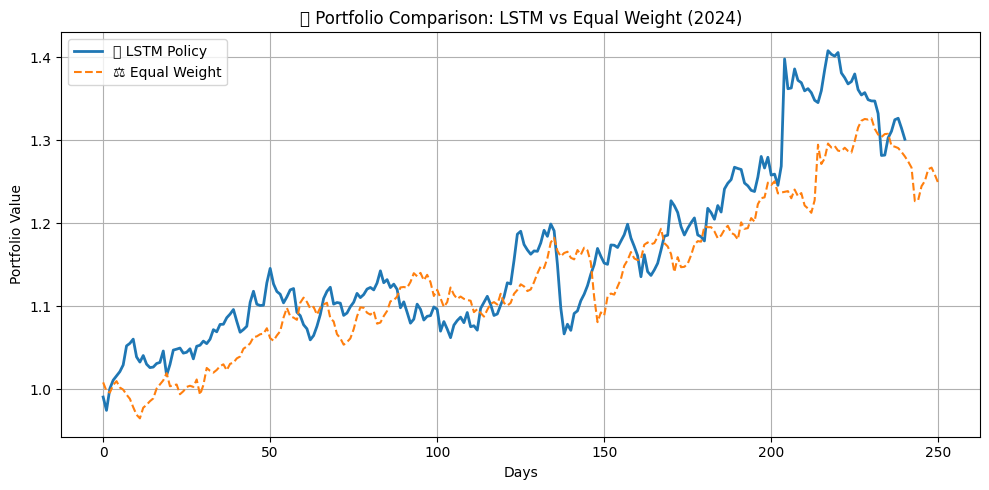

📊 Final Return (LSTM): 30.11%
📊 Final Return (Equal Weight): 24.84%


In [ ]:
# 📦 Equal Weight Backtesting
def backtest_equal_weight(returns_df, initial_cash=1.0):
    weights = torch.tensor([1.0 / returns_df.shape[1]] * returns_df.shape[1], dtype=torch.float32).to(device)
    portfolio_values = [initial_cash]
    cash = initial_cash
    returns_tensor = torch.tensor(returns_df.values, dtype=torch.float32).to(device)

    for r in returns_tensor:
        cash *= (1.0 + torch.dot(weights, r).item())
        portfolio_values.append(cash)

    return portfolio_values[1:]  # to align with LSTM length

# 🧪 Run Equal Weight Backtest
equal_weight_values = backtest_equal_weight(test_returns)

# 🟦 Comparison Plot: LSTM vs Equal Weight
plt.figure(figsize=(10, 5))
plt.plot(portfolio_values, label="📈 LSTM Policy", linewidth=2)
plt.plot(equal_weight_values, label="⚖️ Equal Weight", linestyle="--")
plt.title("📊 Portfolio Comparison: LSTM vs Equal Weight (2024)")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 🧾 Final Returns
lstm_return = portfolio_values[-1] - 1.0
equal_weight_return = equal_weight_values[-1] - 1.0
print(f"📊 Final Return (LSTM): {lstm_return:.2%}")
print(f"📊 Final Return (Equal Weight): {equal_weight_return:.2%}")


C:\Users\Shashwat\AppData\Local\Temp\ipykernel_26708\2429550516.py:13: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


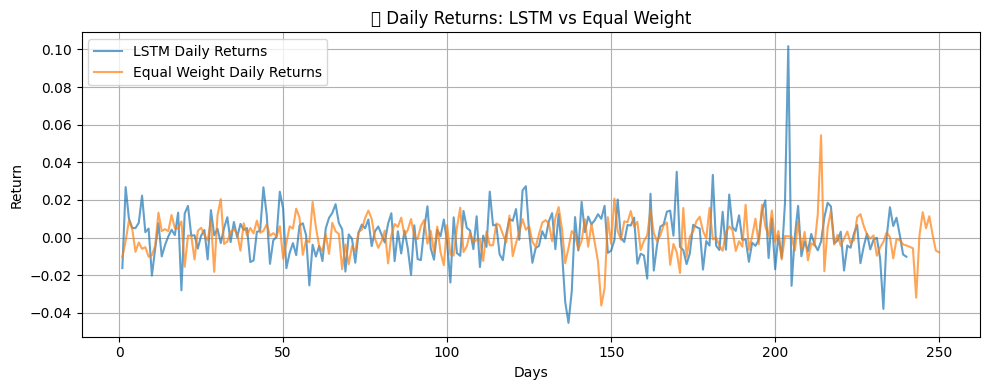

In [ ]:
# 🔄 Convert portfolio values to daily returns
lstm_returns = pd.Series(portfolio_values).pct_change().dropna()
equal_returns = pd.Series(equal_weight_values).pct_change().dropna()

plt.figure(figsize=(10, 4))
plt.plot(lstm_returns, label="LSTM Daily Returns", alpha=0.7)
plt.plot(equal_returns, label="Equal Weight Daily Returns", alpha=0.7)
plt.title("📊 Daily Returns: LSTM vs Equal Weight")
plt.xlabel("Days")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\Shashwat\AppData\Local\Temp\ipykernel_26708\4138230724.py:15: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


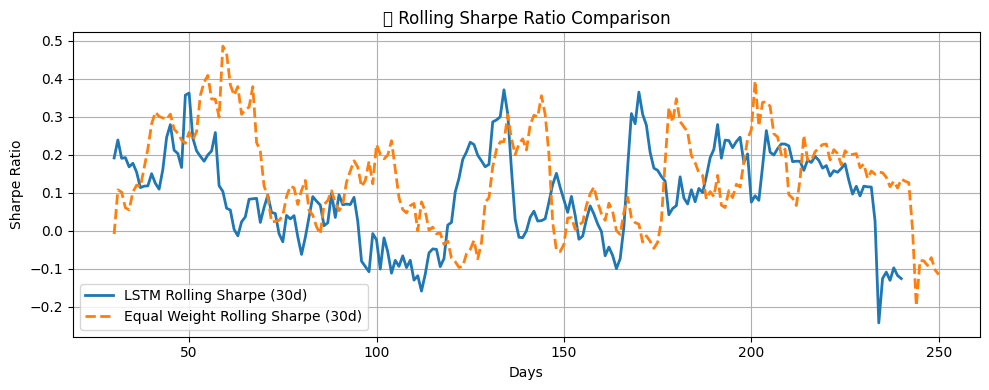

In [ ]:
def rolling_sharpe(returns, window=30):
    return returns.rolling(window).mean() / (returns.rolling(window).std() + 1e-8)

lstm_sharpe = rolling_sharpe(lstm_returns)
equal_sharpe = rolling_sharpe(equal_returns)

plt.figure(figsize=(10, 4))
plt.plot(lstm_sharpe, label="LSTM Rolling Sharpe (30d)", linewidth=2)
plt.plot(equal_sharpe, label="Equal Weight Rolling Sharpe (30d)", linewidth=2, linestyle='--')
plt.title("📈 Rolling Sharpe Ratio Comparison")
plt.xlabel("Days")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\Shashwat\AppData\Local\Temp\ipykernel_26708\11159595.py:16: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Shashwat\.conda\envs\pytorch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


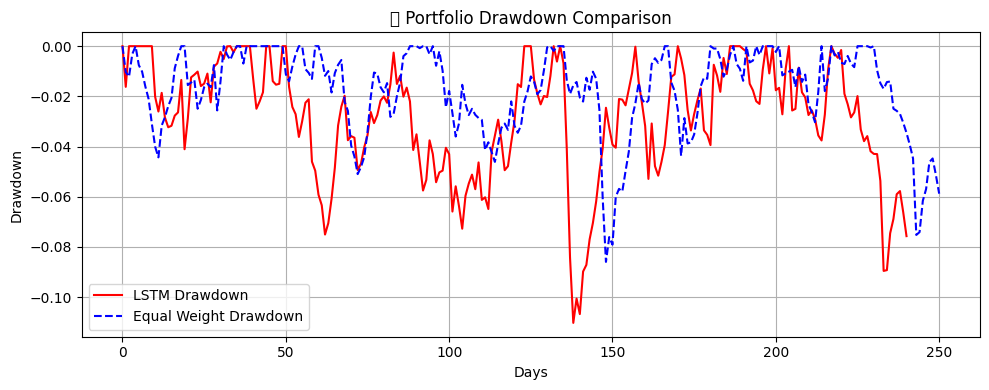

In [ ]:
def compute_drawdown(series):
    cum_max = series.cummax()
    return (series - cum_max) / cum_max

lstm_dd = compute_drawdown(pd.Series(portfolio_values))
equal_dd = compute_drawdown(pd.Series(equal_weight_values))

plt.figure(figsize=(10, 4))
plt.plot(lstm_dd, label="LSTM Drawdown", color='red')
plt.plot(equal_dd, label="Equal Weight Drawdown", color='blue', linestyle='--')
plt.title("📉 Portfolio Drawdown Comparison")
plt.xlabel("Days")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# ✅ Step 1: Align daily returns
aligned_returns = pd.DataFrame({
    "LSTM": lstm_returns.values,
    "EqualWeight": equal_returns.values
})

# ✅ Step 2: Compute rolling alpha (LSTM - Benchmark)
rolling_window = 30
rolling_alpha = aligned_returns["LSTM"].rolling(rolling_window).mean() - aligned_returns["EqualWeight"].rolling(rolling_window).mean()

# ✅ Step 3: Plot rolling alpha
plt.figure(figsize=(10, 4))
plt.plot(rolling_alpha, label=f"Rolling Alpha ({rolling_window}d)", color='green', linewidth=2)
plt.axhline(0, color='black', linestyle='--', alpha=0.6)
plt.title("📈 Rolling Alpha (LSTM vs Equal Weight Benchmark)")
plt.xlabel("Days")
plt.ylabel("Excess Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'pd' is not defined